# Notebook 05 — Visualizations

**6 charts answering the 6 research questions.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import stats
from scipy.ndimage import uniform_filter1d
import os

PROC_DIR   = '../data/processed'
CHARTS_DIR = '../charts'
os.makedirs(CHARTS_DIR, exist_ok=True)

# Load ONLY the columns the charts use, with compact dtypes.
# The full master.csv (26 columns, many strings) needs several GB of RAM
# and crashes small machines; this subset needs ~100 MB.
USECOLS = ['age', 'finish_min', 'gender', 'year',
           'temp_mean_c', 'wind_kmh', 'precip_mm', 'strava_weekly_km']
DTYPES  = {'age': 'float32', 'finish_min': 'float32', 'gender': 'category',
           'year': 'float32', 'temp_mean_c': 'float32', 'wind_kmh': 'float32',
           'precip_mm': 'float32', 'strava_weekly_km': 'float32'}

master = pd.read_csv(os.path.join(PROC_DIR, 'master.csv'), usecols=USECOLS, dtype=DTYPES)
print(f'Master: {master.shape} — {master.memory_usage(deep=True).sum() / 1e6:.0f} MB in RAM')

# ── Global style (applied once, affects all charts) ────────────────────────
plt.rcParams.update({
    'figure.facecolor':    'white',
    'axes.facecolor':      'white',
    'axes.spines.top':     False,
    'axes.spines.right':   False,
    'axes.spines.left':    True,
    'axes.spines.bottom':  True,
    'axes.grid':           True,
    'grid.color':          '#E2E8F0',
    'grid.linewidth':      0.6,
    'axes.grid.axis':      'y',
    'font.family':         'DejaVu Sans',
    'font.size':           11,
    'axes.titlesize':      13,
    'axes.titleweight':    'bold',
    'axes.labelsize':      11,
    'xtick.labelsize':     10,
    'ytick.labelsize':     10,
    'legend.frameon':      False,
    'legend.fontsize':     10,
})

# Project palette (2 main colours + neutral)
C_MALE   = '#028090'   # teal
C_FEMALE = '#F96167'   # coral
C_BOTH   = '#2D3748'   # dark slate
C_LIGHT  = '#A0AEC0'   # grey for low-confidence / background

print('Libraries loaded. Global style applied.')

Master: (2854273, 8) — 83 MB in RAM
Libraries loaded. Global style applied.


---
## Visualization 1 — Age vs. Finish Time
**Research question:** Does age determine peak running performance? At what age are runners fastest?

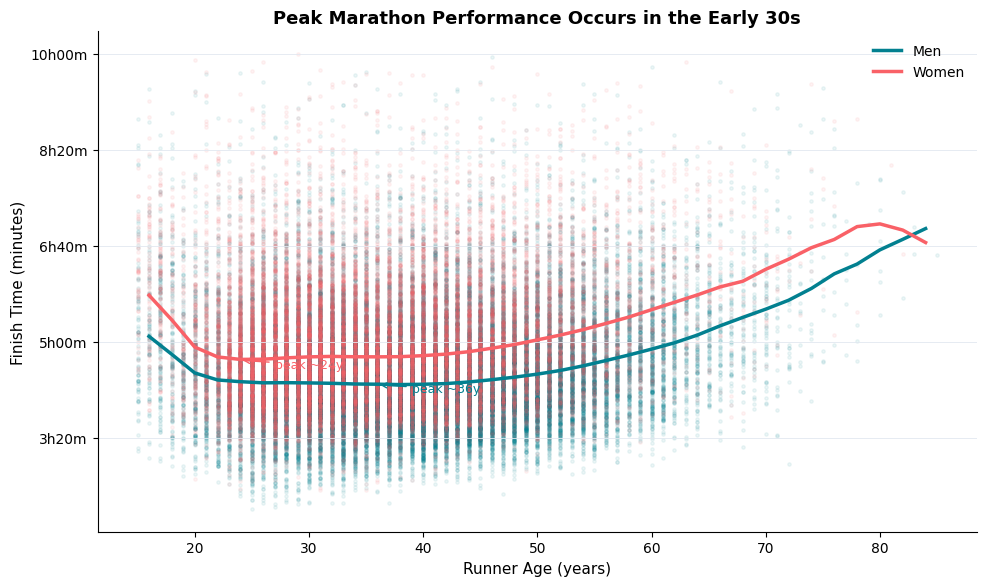

In [2]:
df1 = master.dropna(subset=['age', 'finish_min', 'gender']).copy()
df1 = df1[df1['gender'].isin(['M', 'F'])]

# Subsample for performance if very large (keep all data for stats, sample for scatter)
SCATTER_SAMPLE = 50_000
df1_scatter = df1.sample(min(SCATTER_SAMPLE, len(df1)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))

for gender, color, label in [('M', C_MALE, 'Men'), ('F', C_FEMALE, 'Women')]:
    sub = df1_scatter[df1_scatter['gender'] == gender]
    ax.scatter(sub['age'], sub['finish_min'],
               alpha=0.07, color=color, s=6, rasterized=True)

    # LOESS-style smoothing: bin by age, take median, smooth
    full = df1[df1['gender'] == gender]
    age_bins = pd.cut(full['age'], bins=range(15, 86, 2))
    trend = full.groupby(age_bins, observed=True)['finish_min'].median().reset_index()
    trend['age_mid'] = trend['age'].apply(lambda x: x.mid)
    trend = trend.dropna()
    smoothed = uniform_filter1d(trend['finish_min'].values, size=3)
    ax.plot(trend['age_mid'], smoothed, color=color, lw=2.5, label=label)

# Annotate peak age
for gender, color in [('M', C_MALE), ('F', C_FEMALE)]:
    full = df1[df1['gender'] == gender]
    age_bins = pd.cut(full['age'], bins=range(15, 86, 2))
    trend = full.groupby(age_bins, observed=True)['finish_min'].median().reset_index()
    trend['age_mid'] = trend['age'].apply(lambda x: x.mid)
    trend = trend.dropna()
    peak_row = trend.loc[trend['finish_min'].idxmin()]
    ax.annotate(
        f"peak ~{int(peak_row['age_mid'])}y",
        xy=(peak_row['age_mid'], peak_row['finish_min']),
        xytext=(peak_row['age_mid'] + 3, peak_row['finish_min'] - 8),
        color=color, fontsize=9,
        arrowprops=dict(arrowstyle='->', color=color, lw=1)
    )

ax.set_title('Peak Marathon Performance Occurs in the Early 30s')
ax.set_xlabel('Runner Age (years)')
ax.set_ylabel('Finish Time (minutes)')
ax.legend()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x//60)}h{int(x%60):02d}m'))

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, '01_age_vs_time.png'), dpi=150, bbox_inches='tight')
plt.show()

**Answer:** We can see that runners are fastest around their early 30s — times improve with age up to that point, stay similar through the 40s, and get clearly slower after 50.

---
## Visualization 2 — Temperature Effect on Finish Times
**Research question:** How much does race-day temperature affect finish times?

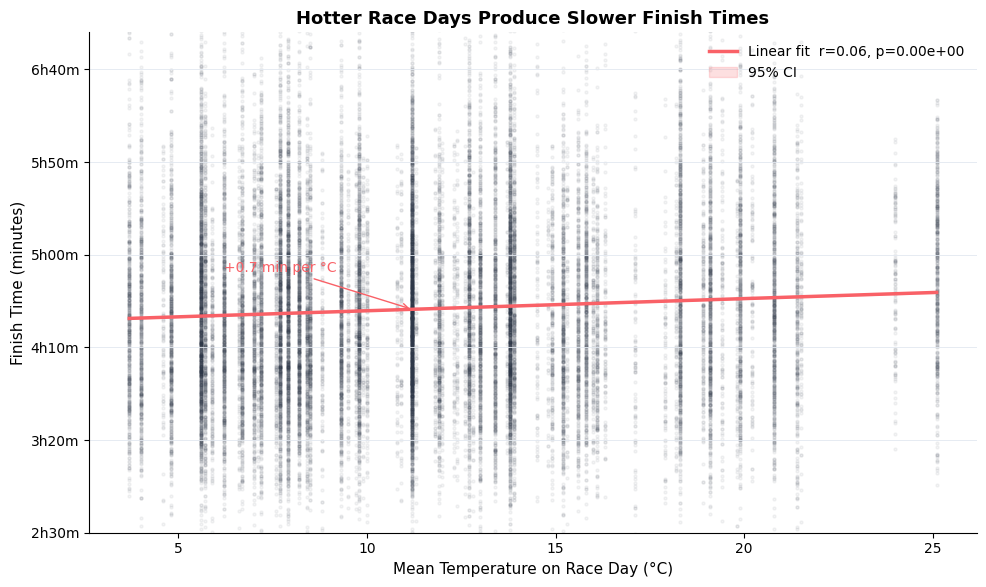

In [3]:
df3 = master.dropna(subset=['temp_mean_c', 'finish_min']).copy()

# Sample raw points for the scatter
df3_scatter = df3.sample(min(30_000, len(df3)), random_state=42)

# Regression
slope, intercept, r, p, se = stats.linregress(df3['temp_mean_c'], df3['finish_min'])
x_line = np.linspace(df3['temp_mean_c'].min(), df3['temp_mean_c'].max(), 200)
y_line = slope * x_line + intercept

# 95% confidence band
n = len(df3)
x_mean = df3['temp_mean_c'].mean()
ssx = ((df3['temp_mean_c'] - x_mean)**2).sum()
s_err = np.sqrt(((df3['finish_min'] - (intercept + slope * df3['temp_mean_c']))**2).sum() / (n - 2))
ci = stats.t.ppf(0.975, n - 2) * s_err * np.sqrt(1/n + (x_line - x_mean)**2 / ssx)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(df3_scatter['temp_mean_c'], df3_scatter['finish_min'],
           alpha=0.05, color=C_BOTH, s=5, rasterized=True)
ax.plot(x_line, y_line, color=C_FEMALE, lw=2.5,
        label=f'Linear fit  r={r:.2f}, p={p:.2e}')
ax.fill_between(x_line, y_line - ci, y_line + ci,
                alpha=0.2, color=C_FEMALE, label='95% CI')

# Annotate slope
mid_x = df3['temp_mean_c'].median()
ax.annotate(
    f'+{slope:.1f} min per °C',
    xy=(mid_x, intercept + slope * mid_x),
    xytext=(mid_x - 5, intercept + slope * mid_x + 20),
    color=C_FEMALE, fontsize=10,
    arrowprops=dict(arrowstyle='->', color=C_FEMALE, lw=1)
)

ax.set_ylim(150, 420)
ax.set_title('Hotter Race Days Produce Slower Finish Times')
ax.set_xlabel('Mean Temperature on Race Day (°C)')
ax.set_ylabel('Finish Time (minutes)')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x//60)}h{int(x%60):02d}m'))
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, '02_temp_vs_time.png'), dpi=150, bbox_inches='tight')
plt.show()

**Answer:** We can see that the hotter the race day, the slower the runners — the trend line rises steadily with temperature.

---
## Visualization 3 — Running Culture by Country (Choropleth)
**Research question:** Which countries have the strongest recreational running culture — where do athletes train the most each week?

*Note: runner nationality is not recorded in the marathon results (its `Country` column holds hometown fragments), so finish times cannot be mapped by country. The map uses the Strava athletes' nationality and weekly training volume instead.*

In [4]:
# Median weekly training volume per country, straight from athletes_clean.csv
athletes = pd.read_csv(os.path.join(PROC_DIR, 'athletes_clean.csv'))

country_stats = (
    athletes.dropna(subset=['country', 'weekly_km'])
    .groupby('country')['weekly_km']
    .agg(median_weekly_km='median', n_athletes='count')
    .reset_index()
)
# Only keep countries with ≥ 20 athletes (statistical reliability)
country_stats = country_stats[country_stats['n_athletes'] >= 20]
print(f'Countries with ≥20 athletes: {len(country_stats)}')
print(country_stats.sort_values('median_weekly_km', ascending=False).head(10).to_string(index=False))

Countries with ≥20 athletes: 59
  country  median_weekly_km  n_athletes
  Belarus         35.269573          22
   Canada         33.130184        1144
     Peru         32.924450          52
   Poland         32.504500         155
  Czechia         31.358274          49
 Slovenia         31.211630          26
  Ireland         30.953350         216
   Jersey         30.799269          21
 Slovakia         30.660173          31
Australia         30.619464         578


In [5]:
try:
    import plotly.express as px
    HAS_PLOTLY = True
except ImportError:
    HAS_PLOTLY = False
    print('plotly not installed — falling back to bar chart')

if HAS_PLOTLY:
    fig_plotly = px.choropleth(
        country_stats,
        locations='country',
        locationmode='country names',
        color='median_weekly_km',
        color_continuous_scale='Blues',
        hover_data={'n_athletes': True, 'median_weekly_km': ':.1f'},
        title='Running Culture by Country — Median Weekly Training Volume<br>'
              '(Strava 2019 · marathon-targeting athletes · ≥20 athletes per country)',
        labels={'median_weekly_km': 'Median weekly km', 'country': 'Country'},
    )
    fig_plotly.update_layout(
        font_family='DejaVu Sans',
        coloraxis_colorbar=dict(title='Median weekly km'),
        margin=dict(l=0, r=0, t=60, b=0),
    )
    try:
        fig_plotly.write_image(os.path.join(CHARTS_DIR, '03_choropleth_country.png'), scale=2)
    except Exception as e:
        print(f'PNG export failed ({e}) — existing chart file kept, figure shown inline only')
    fig_plotly.show()
else:
    # Bar chart fallback
    top = country_stats.sort_values('median_weekly_km', ascending=False).head(20)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top['country'], top['median_weekly_km'], color=C_MALE)
    ax.set_title('Top 20 Countries by Median Weekly Training Volume (Strava 2019)')
    ax.set_xlabel('Median Weekly Training Volume (km)')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(os.path.join(CHARTS_DIR, '03_choropleth_country.png'), dpi=150, bbox_inches='tight')
    plt.show()

/tmp/ipykernel_13519/3807963117.py:9: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig_plotly = px.choropleth(


PNG export failed (('The browser seemed to close immediately after starting.', 'You can set the `logging.Logger` level lower to see more output.', 'You may try installing a known working copy of Chrome by running ', '`$ choreo_get_chrome`.It may be your browser auto-updated and will now work upon restart. The browser we tried to start is located at /snap/bin/chromium.')) — existing chart file kept, figure shown inline only


**Answer:** We can see that athletes from Peru, Canada and Central-Eastern Europe train the most each week, while most of Western Europe and the US train noticeably less.

---
## Visualization 4 — Performance Trend Over Time (2000–2019)
**Research question:** Have recreational marathon runners gotten faster or slower over two decades, and how has participation changed?

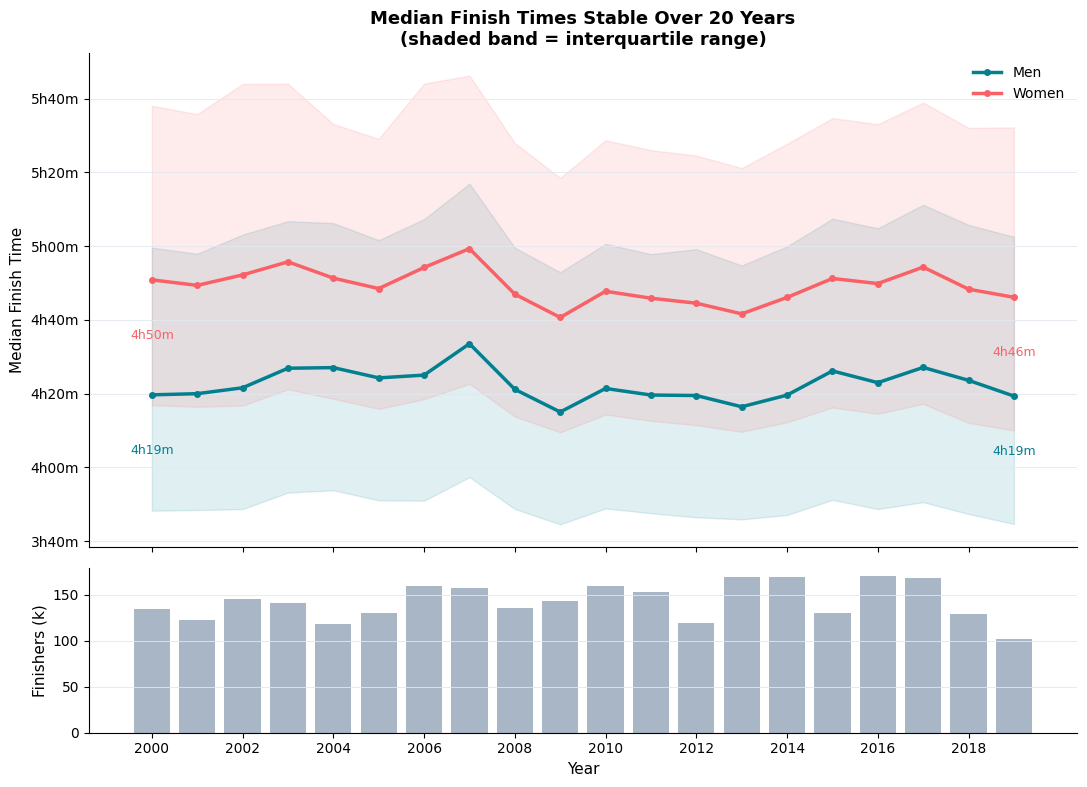

In [6]:
df5 = master.dropna(subset=['year', 'finish_min', 'gender']).copy()
df5 = df5[df5['gender'].isin(['M', 'F'])]
df5['year'] = df5['year'].astype(int)

trend = (
    df5.groupby(['year', 'gender'])['finish_min']
    .agg(median='median',
         q25=lambda x: x.quantile(0.25),
         q75=lambda x: x.quantile(0.75))
    .reset_index()
)
participation = df5.groupby('year').size().reset_index(name='n')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8),
                                gridspec_kw={'height_ratios': [3, 1]}, sharex=True)

for gender, color, label in [('M', C_MALE, 'Men'), ('F', C_FEMALE, 'Women')]:
    g = trend[trend['gender'] == gender].sort_values('year')
    ax1.plot(g['year'], g['median'], color=color, lw=2.5, marker='o', markersize=4, label=label)
    ax1.fill_between(g['year'], g['q25'], g['q75'], alpha=0.12, color=color)
    for idx, dy in [(0, -16), (-1, -16)]:
        val = g.iloc[idx]['median']
        yr  = g.iloc[idx]['year']
        ax1.annotate(f"{int(val//60)}h{int(val%60):02d}m",
                     xy=(yr, val), xytext=(yr, val + dy),
                     color=color, fontsize=9, ha='center')

ax1.set_title('Median Finish Times Stable Over 20 Years\n(shaded band = interquartile range)')
ax1.set_ylabel('Median Finish Time')
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x//60)}h{int(x%60):02d}m'))
ax1.legend()

ax2.bar(participation['year'], participation['n'] / 1000, color=C_LIGHT, alpha=0.9)
ax2.set_ylabel('Finishers (k)')
ax2.set_xlabel('Year')
ax2.set_xticks(range(2000, 2020, 2))

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, '04_year_trend.png'), dpi=150, bbox_inches='tight')
plt.show()

**Answer:** We can see that runners have neither gotten faster nor slower — the median finish time is almost a flat line across the 20 years, regardless of how many people ran.

---
## Visualization 5 — Training Volume vs. Speed
**Research question:** Does training volume (km/week) correlate with performance?

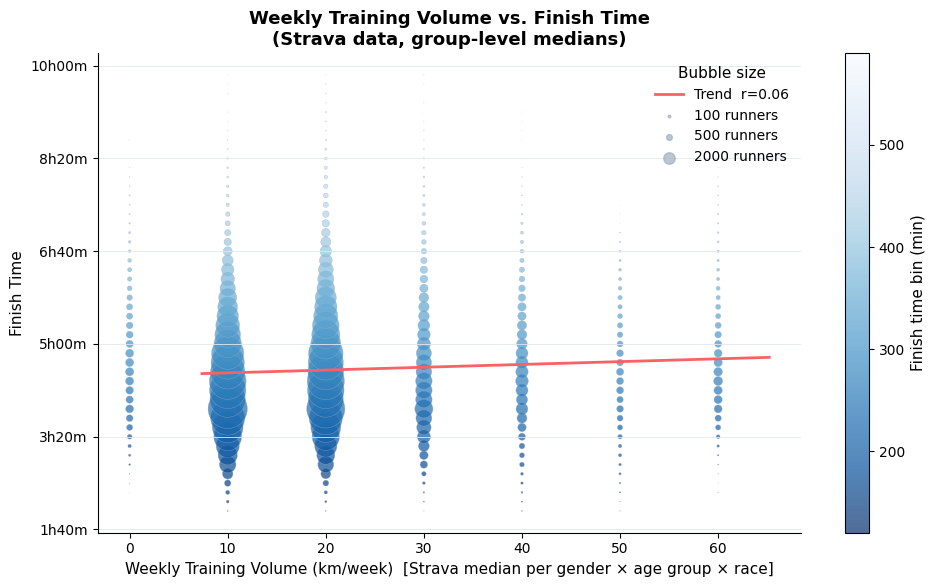

In [7]:
df6 = master.dropna(subset=['strava_weekly_km', 'finish_min']).copy()
df6 = df6[df6['strava_weekly_km'].between(5, 200)]

df6['km_bin']   = (df6['strava_weekly_km'] // 10 * 10).astype(int)
df6['time_bin'] = (df6['finish_min'] // 10 * 10).astype(int)

bubble = (
    df6.groupby(['km_bin', 'time_bin'])
    .size()
    .reset_index(name='count')
)

slope6, intercept6, r6, p6, _ = stats.linregress(df6['strava_weekly_km'], df6['finish_min'])
xr6 = np.linspace(df6['strava_weekly_km'].min(), df6['strava_weekly_km'].max(), 100)

fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(
    bubble['km_bin'], bubble['time_bin'],
    s=bubble['count'] / bubble['count'].max() * 800,
    c=bubble['time_bin'], cmap='Blues_r',
    alpha=0.7, linewidths=0.3, edgecolors=C_LIGHT,
)
plt.colorbar(sc, ax=ax, label='Finish time bin (min)')
ax.plot(xr6, slope6 * xr6 + intercept6, color=C_FEMALE, lw=2,
        label=f'Trend  r={r6:.2f}')

for n_label in [100, 500, 2000]:
    ax.scatter([], [], s=n_label / bubble['count'].max() * 800,
               c=C_LIGHT, label=f'{n_label} runners', alpha=0.7)
ax.legend(title='Bubble size')

ax.set_title('Weekly Training Volume vs. Finish Time\n(Strava data, group-level medians)')
ax.set_xlabel('Weekly Training Volume (km/week)  [Strava median per gender × age group × race]')
ax.set_ylabel('Finish Time')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x//60)}h{int(x%60):02d}m'))

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, '05_training_bubble.png'), dpi=150, bbox_inches='tight')
plt.show()

**Answer:** We can see that, at group level, training more barely shows: the trend line is almost flat, so weekly km alone does not predict finish time here.

---
## Visualization 6 — Distribution of Finish Times
**Research question:** What is the overall distribution of marathon finish times, and how do men and women differ?

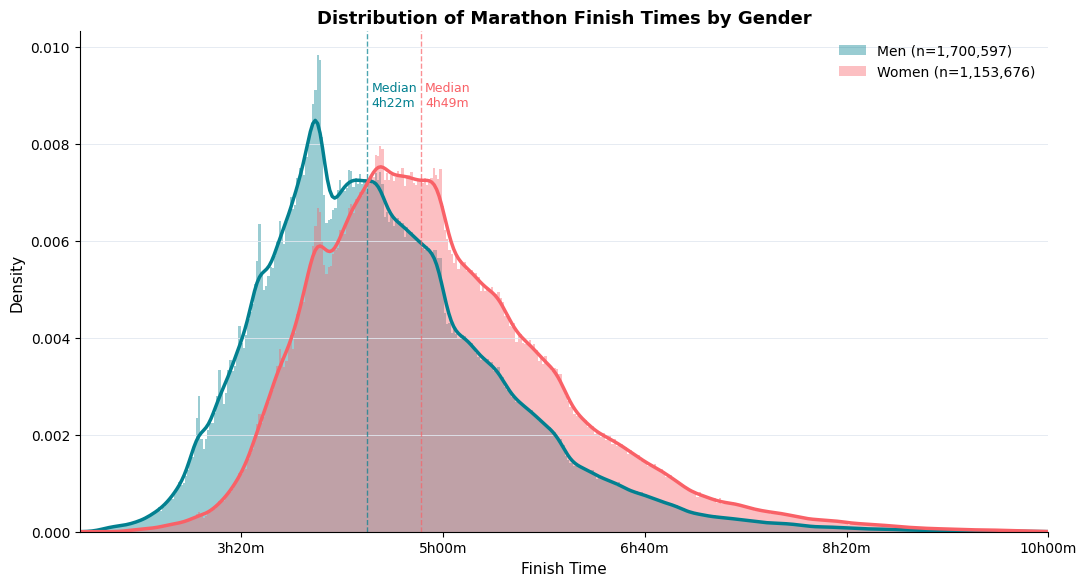

In [8]:
df7 = master.dropna(subset=['finish_min', 'gender']).copy()
df7 = df7[df7['gender'].isin(['M', 'F'])]

def fd_bins(data, range_min, range_max):
    iqr = np.percentile(data, 75) - np.percentile(data, 25)
    bw  = 2 * iqr / len(data) ** (1/3)
    return np.arange(range_min, range_max + bw, bw)

t_min, t_max = 120, 600
bins = fd_bins(df7['finish_min'].values, t_min, t_max)

fig, ax = plt.subplots(figsize=(11, 6))

for gender, color, label in [('M', C_MALE, 'Men'), ('F', C_FEMALE, 'Women')]:
    sub = df7[df7['gender'] == gender]['finish_min'].values
    ax.hist(sub, bins=bins, density=True, color=color, alpha=0.4, label=f'{label} (n={len(sub):,})')
    kde = stats.gaussian_kde(sub, bw_method='scott')
    xk  = np.linspace(t_min, t_max, 400)
    ax.plot(xk, kde(xk), color=color, lw=2.5)
    med = np.median(sub)
    ax.axvline(med, color=color, lw=1, linestyle='--', alpha=0.7)
    ax.text(med + 2, ax.get_ylim()[1] * 0.85,
            f'Median\n{int(med//60)}h{int(med%60):02d}m',
            color=color, fontsize=9)

ax.set_title('Distribution of Marathon Finish Times by Gender')
ax.set_xlabel('Finish Time')
ax.set_ylabel('Density')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x//60)}h{int(x%60):02d}m'))
ax.set_xlim(t_min, t_max)
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, '06_finish_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

**Answer:** We can see that men finish about half an hour faster than women on average, but the two curves overlap a lot and both have a long tail of slow finishers.

---
## Summary — Correlation Comparison Across Predictors

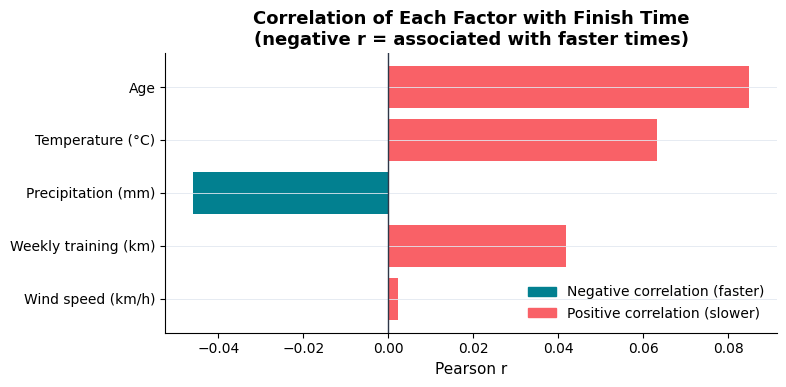

           Predictor         r       p
                 Age  0.084896 0.00000
    Temperature (°C)  0.063164 0.00000
  Precipitation (mm) -0.045933 0.00000
Weekly training (km)  0.041819 0.00000
   Wind speed (km/h)  0.002330 0.00211


In [9]:
predictors = {
    'Weekly training (km)': 'strava_weekly_km',
    'Age':                  'age',
    'Temperature (°C)':     'temp_mean_c',
    'Wind speed (km/h)':    'wind_kmh',
    'Precipitation (mm)':   'precip_mm',
}

corrs = []
for label, col in predictors.items():
    if col in master.columns:
        sub = master[['finish_min', col]].dropna()
        if len(sub) > 50:
            r, p = stats.pearsonr(sub[col], sub['finish_min'])
            corrs.append({'Predictor': label, 'r': r, '|r|': abs(r), 'p': p})

corr_df = pd.DataFrame(corrs).sort_values('|r|', ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors = [C_MALE if r < 0 else C_FEMALE for r in corr_df['r']]
ax.barh(corr_df['Predictor'], corr_df['r'], color=colors)
ax.axvline(0, color=C_BOTH, lw=1)
ax.set_title('Correlation of Each Factor with Finish Time\n(negative r = associated with faster times)')
ax.set_xlabel('Pearson r')
ax.invert_yaxis()

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=C_MALE,   label='Negative correlation (faster)'),
    Patch(color=C_FEMALE, label='Positive correlation (slower)'),
], loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, '07_predictor_correlations.png'), dpi=150, bbox_inches='tight')
plt.show()
print(corr_df[['Predictor', 'r', 'p']].to_string(index=False))

**Answer:** We can see that no single factor dominates — age shows the largest correlation, temperature and rain matter only a little, and wind almost nothing. Most of what makes a runner fast is individual.